# 01 · Calidad de datos y análisis exploratorio

**TPO Ciencia de Datos · ¿Dónde faltan cajeros Link en CABA?**

Fase de CRISP-DM: **comprensión de los datos**. Antes de modelar respondemos tres preguntas que pide la consigna:
**qué hay**, **qué falta** y **qué llamó la atención**.

1. Inventario de fuentes
2. Calidad de datos con las seis dimensiones de DAMA (clase 3)
3. Análisis exploratorio con los cinco tipos de EDA (clase 4)
4. Hallazgos que condicionan el modelado

In [1]:
import json, sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import estilo as e, features as f

e.mpl_estilo()
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
BASE, PROC, FIG = RAIZ / "data/base", RAIZ / "data/processed", RAIZ / "docs/figuras"
FIG.mkdir(parents=True, exist_ok=True)

cajeros = f.cargar_cajeros()
barrios = f.cargar_barrios()
censo = pd.read_parquet(BASE / "censo2022-caba-largo.parquet")
radios = gpd.read_file(BASE / "censo2022-caba-radios.geojson")
osm = pd.read_csv(BASE / "osm-caba-puntos.csv")
molinetes = pd.read_csv(BASE / "molinetes-2025-estacion-hora.csv")
usos = pd.read_parquet(BASE / "usos-suelo-2022-2024.parquet")
hexes = pd.read_parquet(PROC / "resultados_hex.parquet")
print("Listo")

Listo


## 1. Inventario de fuentes

Seis fuentes de cuatro organismos distintos. Cada una aporta una pieza: la **oferta** (cajeros) y la **demanda** (residentes, actividad comercial y flujo de pasajeros).

In [2]:
inventario = pd.DataFrame([
    ["Cajeros automáticos", "GCBA · BA Data", "≈2017 (ver oportunidad)", len(cajeros), "punto (cajero)", "Oferta: banco, red, terminales"],
    ["Censo 2022 por radio", "INDEC", "2022", censo["id_geo"].nunique(), "radio censal", "Residentes y perfil socioeconómico"],
    ["Polígonos de radios censales", "INDEC / CONICET", "2022", len(radios), "polígono", "Ubicar a los residentes"],
    ["Molinetes del subte", "SBASE · BA Data", "2025 (335 días)", molinetes[["linea", "estacion"]].drop_duplicates().shape[0], "estación × hora × tipo de día", "Flujo de pasajeros"],
    ["Usos del suelo", "GCBA · BA Data", "2022–2024", len(usos), "parcela", "Comercio, oficinas, vivienda"],
    ["OpenStreetMap", "Colaboradores de OSM", "2026", len(osm), "punto", "Comercios, estaciones, bancos"],
    ["Barrios", "GCBA · BA Data", "vigente", len(barrios), "polígono", "Límites y nombres"],
], columns=["Fuente", "Organismo", "Período", "Registros", "Granularidad", "Qué aporta"])
inventario

,Fuente,Organismo,Período,Registros,Granularidad,Qué aporta
0,Cajeros automáticos,GCBA · BA Data,≈2017 (ver oportunidad),1279,punto (cajero),"Oferta: banco, red, terminales"
1,Censo 2022 por radio,INDEC,2022,3820,radio censal,Residentes y perfil socioeconómico
2,Polígonos de radios censales,INDEC / CONICET,2022,3820,polígono,Ubicar a los residentes
3,Molinetes del subte,SBASE · BA Data,2025 (335 días),106,estación × hora × tipo de día,Flujo de pasajeros
4,Usos del suelo,GCBA · BA Data,2022–2024,417764,parcela,"Comercio, oficinas, vivienda"
5,OpenStreetMap,Colaboradores de OSM,2026,29156,punto,"Comercios, estaciones, bancos"
6,Barrios,GCBA · BA Data,vigente,48,polígono,Límites y nombres


## 2. Calidad de datos (DAMA)

Medimos las seis dimensiones vistas en clase con su métrica:

| Dimensión | Pregunta | Métrica |
|---|---|---|
| Completitud | ¿Están todos los datos que se esperan? | completos / total |
| Validez | ¿Respeta formato, tipo y rango? | válidos / total |
| Unicidad | ¿Cada entidad aparece una sola vez? | 1 − duplicados / total |
| Consistencia | ¿El mismo dato coincide entre fuentes? | coincidencias / comparados |
| Exactitud | ¿Refleja la realidad? | correctos / verificados |
| Oportunidad | ¿Está actualizado cuando se lo necesita? | fecha de uso − fecha del dato |

### 2.1 Cajeros automáticos (la fuente crítica)

In [3]:
caba = barrios.union_all()
pts = gpd.GeoSeries(gpd.points_from_xy(cajeros["lon"], cajeros["lat"]), crs="EPSG:4326")

obligatorios = ["lat", "lon", "banco", "red", "terminales", "barrio", "comuna"]
completitud = cajeros[obligatorios].notna().all(axis=1).mean()
validez = (pts.within(caba.buffer(0.001)) & cajeros["red"].isin(["LINK", "BANELCO"]) & (cajeros["terminales"] >= 1)).mean()
unicidad = 1 - cajeros.duplicated(["lat", "lon", "banco"]).mean()

# Consistencia: ¿el barrio informado coincide con el barrio donde cae el punto?
asignado = gpd.sjoin(gpd.GeoDataFrame(cajeros[["barrio"]], geometry=pts), barrios.rename(columns={"barrio": "barrio_geo"}),
                     how="left", predicate="within")
norm = lambda s: s.fillna("").map(f.normalizar)
comparables = asignado["barrio"].notna() & asignado["barrio_geo"].notna()
consistencia = (norm(asignado.loc[comparables, "barrio"]) == norm(asignado.loc[comparables, "barrio_geo"])).mean()

# Exactitud contra una referencia actual: de los cajeros que OSM tiene mapeados en 2026,
# ¿cuántos tienen un cajero del listado a menos de 150 m?
from src import modelos as m
osm_caj = osm[osm["categoria"] == "cajero"]
nuevos = m.cajeros_nuevos_osm(osm, cajeros, umbral_m=150)
exactitud = 1 - len(nuevos) / len(osm_caj)

calidad_cajeros = pd.DataFrame([
    ["Completitud", completitud, f"{(~cajeros[obligatorios].notna().all(axis=1)).sum()} registros con algún campo obligatorio vacío"],
    ["Validez", validez, "coordenadas dentro de CABA, red conocida, terminales ≥ 1"],
    ["Unicidad", unicidad, f"{cajeros.duplicated(['lat', 'lon', 'banco']).sum()} duplicados por ubicación y banco"],
    ["Consistencia", consistencia, "barrio informado vs. barrio donde cae el punto"],
    ["Exactitud", exactitud, f"{len(osm_caj) - len(nuevos)} de {len(osm_caj)} cajeros de OSM 2026 tienen uno del listado a < 150 m"],
], columns=["Dimensión", "Indicador", "Detalle"])
calidad_cajeros.style.format({"Indicador": "{:.1%}"})

,Dimensión,Indicador,Detalle
0,Completitud,97.0%,39 registros con algún campo obligatorio vacío
1,Validez,100.0%,"coordenadas dentro de CABA, red conocida, terminales ≥ 1"
2,Unicidad,98.9%,14 duplicados por ubicación y banco
3,Consistencia,96.9%,barrio informado vs. barrio donde cae el punto
4,Exactitud,95.6%,197 de 206 cajeros de OSM 2026 tienen uno del listado a < 150 m


**Oportunidad: el problema más serio.** El portal informa una actualización en 2026, pero los bancos que aparecen
cuentan otra historia. Buscamos entidades que dejaron de existir o cambiaron de nombre:

In [4]:
senales = {
    "CitiBank": "Citi vendió su banca minorista en Argentina en 2017",
    "BBVA Banco Francés": "pasó a llamarse BBVA Argentina en 2019",
    "Banco Santander Río": "pasó a llamarse Santander Argentina en 2019",
    "HSBC Bank Argentina": "pasó a ser Galicia Más en 2024",
}
evidencia = (cajeros[cajeros["banco"].isin(senales)].groupby("banco")
             .agg(ubicaciones=("id", "count"), terminales=("terminales", "sum")).reset_index())
evidencia["qué pasó"] = evidencia["banco"].map(senales)
print(f"{evidencia['ubicaciones'].sum()} de {len(cajeros)} ubicaciones ({evidencia['ubicaciones'].sum()/len(cajeros):.0%}) "
      "están a nombre de entidades que ya no operan con ese nombre.")
evidencia

395 de 1279 ubicaciones (31%) están a nombre de entidades que ya no operan con ese nombre.


,banco,ubicaciones,terminales,qué pasó
0,BBVA Banco Francés,113,268,pasó a llamarse BBVA Argentina en 2019
1,Banco Santander Río,168,349,pasó a llamarse Santander Argentina en 2019
2,CitiBank,32,87,Citi vendió su banca minorista en Argentina en...
3,HSBC Bank Argentina,82,171,pasó a ser Galicia Más en 2024



**Lectura.** La métrica de *oportunidad* es fecha de uso − fecha del dato: usamos el listado en octubre de 2026 y el
relevamiento es de alrededor de 2017, **unos nueve años**. 395 de 1.279 ubicaciones
(31 %) están a nombre de entidades que ya no operan con ese nombre. El portal informa una fecha de
actualización reciente porque se actualizan los metadatos, no el relevamiento.

**Qué hacemos con esto:** (1) leemos la oferta como una foto de ≈2017 y lo decimos en la defensa; (2) validamos contra los
cajeros mapeados en OpenStreetMap en 2026 (notebook 02, §7); (3) la app permite cargar el listado actual, que Red Link sí
tiene. El resto de las dimensiones del listado da bien: está completo, es válido y no tiene duplicados.

### 2.2 Censo, molinetes, usos del suelo y OpenStreetMap

In [5]:
pob_radio = censo[censo["codigo_variable"] == "PERSONA_P02"].groupby("id_geo")["conteo"].sum()
variables = censo.groupby("id_geo")["codigo_variable"].nunique()
POB_OFICIAL_CABA_2022 = 3_121_707  # INDEC, resultados definitivos del Censo 2022
radios_ids = set(radios["id_geo"])

molinetes_ruido = molinetes["estacion"].isin(["#N/D", "Prueba", "CochePM"]) | (molinetes["linea"] == "PRUEBA")
osm_atm = osm[osm["categoria"] == "cajero"]

otras = pd.DataFrame([
    ["Censo", "Completitud", (variables == variables.max()).mean(), "radios con las 9 variables"],
    ["Censo", "Exactitud", pob_radio.sum() / POB_OFICIAL_CABA_2022, f"{pob_radio.sum():,.0f} habitantes vs. {POB_OFICIAL_CABA_2022:,} oficiales"],
    ["Censo", "Consistencia", len(radios_ids & set(pob_radio.index)) / len(pob_radio), "radios con datos que tienen polígono"],
    ["Molinetes", "Completitud", molinetes.groupby("tipo_dia")["dias"].first().sum() / 365, "días de 2025 con datos"],
    ["Molinetes", "Validez", 1 - molinetes_ruido.mean(), f"{molinetes_ruido.sum()} filas de prueba o sin estación (#N/D)"],
    ["Usos del suelo", "Completitud", usos["TIPO1"].notna().mean(), "parcelas con uso informado"],
    ["Usos del suelo", "Validez", usos["ESTADO"].isin(["ACTIVO", "INACTIVO"]).mean(), "estado ACTIVO/INACTIVO o no aplica"],
    ["OpenStreetMap", "Completitud", osm_atm["red"].notna().mean(), "cajeros de OSM con la red (Link/Banelco) cargada"],
    ["OpenStreetMap", "Exactitud", len(osm_atm) / len(cajeros), f"{len(osm_atm)} cajeros mapeados vs. {len(cajeros)} del listado oficial"],
], columns=["Fuente", "Dimensión", "Indicador", "Detalle"])
otras.style.format({"Indicador": "{:.1%}"})

,Fuente,Dimensión,Indicador,Detalle
0,Censo,Completitud,100.0%,radios con las 9 variables
1,Censo,Exactitud,99.2%,"3,095,454 habitantes vs. 3,121,707 oficiales"
2,Censo,Consistencia,100.0%,radios con datos que tienen polígono
3,Molinetes,Completitud,91.8%,días de 2025 con datos
4,Molinetes,Validez,99.1%,38 filas de prueba o sin estación (#N/D)
5,Usos del suelo,Completitud,100.0%,parcelas con uso informado
6,Usos del suelo,Validez,97.5%,estado ACTIVO/INACTIVO o no aplica
7,OpenStreetMap,Completitud,83.0%,cajeros de OSM con la red (Link/Banelco) cargada
8,OpenStreetMap,Exactitud,16.1%,206 cajeros mapeados vs. 1279 del listado oficial



**Lectura.**
- **Censo:** la base por radio suma 3.095.454 habitantes, el 99,2 % del total oficial de CABA
  (3.121.707). La diferencia es chica; posiblemente corresponde a población que no se asigna a un radio (por ejemplo, en
  situación de calle).
- **Molinetes:** hay datos para 335 de los 365 días de 2025 (91,8 %). Además se descartan
  filas de prueba y estaciones cargadas en líneas que no les corresponden. Los feriados que caen en día de semana cuentan
  como días hábiles: el promedio hábil queda levemente subestimado.
- **Usos del suelo:** el CSV oficial **no trae coordenadas**; las tomamos del shapefile (99,99 % de las parcelas ubicadas).
- **OpenStreetMap:** tiene 206 cajeros contra 1.279 del listado oficial: está **incompleto**,
  así que no sirve para medir la oferta, pero sí como referencia actual de dónde aparecieron cajeros nuevos.

## 3. Análisis exploratorio (los cinco tipos)

La unidad de análisis es el **hexágono H3** (resolución 9). Las variables con `_k1` suman el hexágono y sus seis vecinos:
el **área de influencia** de un cajero, unos 400 m a la redonda.

### Tipo 1 · Univariante no gráfico

In [6]:
cols = {"poblacion": "Residentes", "term_total": "Terminales (todas las redes)", "term_link": "Terminales Link",
        "term_banelco": "Terminales Banelco", "actividad_osm": "Comercios y servicios (OSM)", "pax_subte_habil": "Pasajeros de subte (día hábil)"}
modelables = hexes[hexes["esperado_total_k1"].notna()]
desc = modelables[list(cols)].describe(percentiles=[.25, .5, .75, .95]).T
desc["% ceros"] = (modelables[list(cols)] == 0).mean()
desc["asimetría"] = modelables[list(cols)].skew()
desc.rename(index=cols)

,count,mean,std,min,25%,50%,75%,95%,max,% ceros,asimetría
Residentes,"2,740.00","1,126.78",947.63,0.55,461.63,943.01,"1,509.25","3,092.73","5,369.10",0.00,1.21
Terminales (todas las redes),"2,740.00",0.97,3.44,0.00,0.00,0.00,0.00,6.00,87.00,0.78,11.27
Terminales Link,"2,740.00",0.34,1.63,0.00,0.00,0.00,0.00,2.00,46.00,0.89,13.77
Terminales Banelco,"2,740.00",0.64,2.25,0.00,0.00,0.00,0.00,4.00,47.00,0.83,8.51
Comercios y servicios (OSM),"2,740.00",10.09,17.49,0.00,1.00,4.00,12.00,42.05,209.00,0.22,4.53
Pasajeros de subte (día hábil),"2,740.00",252.17,"1,842.41",0.00,0.00,0.00,0.00,0.00,"54,272.00",0.97,13.79



**Lectura.** Los conteos son muy asimétricos: el **78 %** de los hexágonos no tiene ninguna terminal y
el **89 %** no tiene ninguna Link, pero el máximo llega a 87. La media
describe una zona que casi no existe. Dos consecuencias para el modelado: medir en el **área de influencia** (hexágono +
vecinos) para suavizar, y usar modelos de **conteo** (Poisson) en lugar de una regresión lineal común.

### Tipo 2 · Univariante gráfico

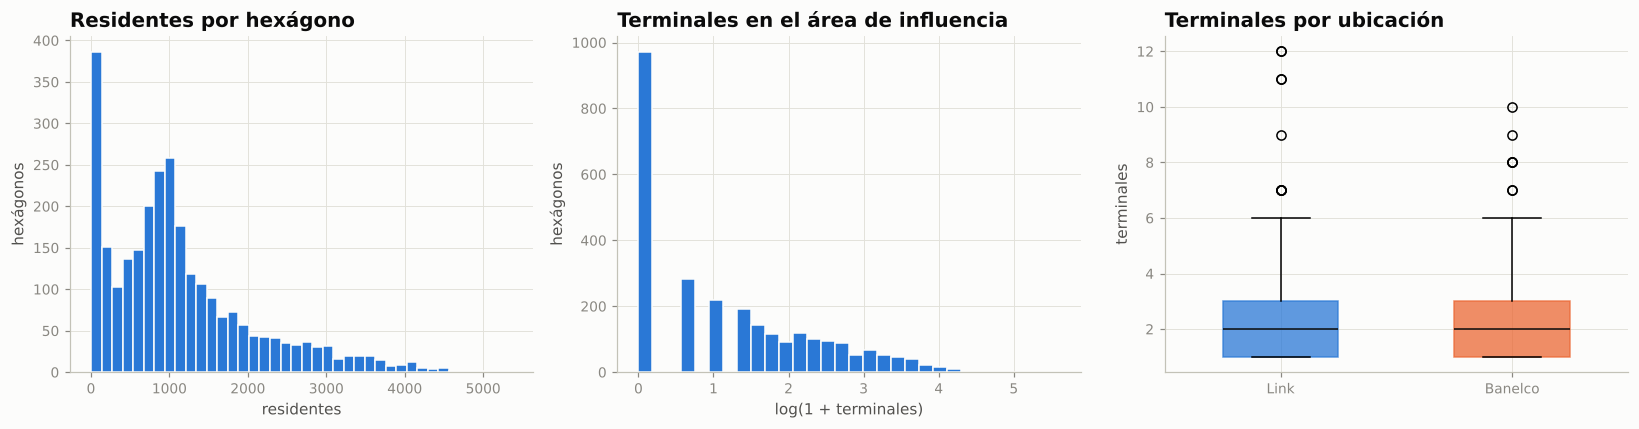

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(modelables["poblacion"], bins=40, color=e.LINK, edgecolor=e.FONDO, linewidth=1)
ax[0].set(title="Residentes por hexágono", xlabel="residentes", ylabel="hexágonos")
ax[1].hist(np.log1p(modelables["term_total_k1"]), bins=30, color=e.LINK, edgecolor=e.FONDO, linewidth=1)
ax[1].set(title="Terminales en el área de influencia", xlabel="log(1 + terminales)", ylabel="hexágonos")
por_ubic = cajeros.assign(red=cajeros["red"].str.title())
datos = [por_ubic.loc[por_ubic["red"] == r, "terminales"] for r in ["Link", "Banelco"]]
bp = ax[2].boxplot(datos, tick_labels=["Link", "Banelco"], patch_artist=True, widths=0.5, medianprops={"color": e.TINTA})
for parche, c in zip(bp["boxes"], [e.LINK, e.BANELCO]):
    parche.set_facecolor(c); parche.set_alpha(0.75); parche.set_edgecolor(c)
ax[2].set(title="Terminales por ubicación", ylabel="terminales")
fig.tight_layout(); fig.savefig(FIG / "eda_univariante.png"); plt.show()


**Lectura.** Los residentes se reparten de forma bastante pareja (la ciudad es densa casi en todas partes), mientras que
las terminales tienen una cola larga: pocas zonas concentran muchísimas. Por ubicación, las dos redes tienen una mediana
de 2 terminales; Link tiene más casos extremos (hasta
12 terminales en un mismo punto, típicamente sucursales grandes de
bancos públicos). La caja muestra la mediana y el rango intercuartil; los puntos sueltos son los casos extremos.

### Tipo 3 · Multivariante no gráfico

In [8]:
vars_corr = {"poblacion_k1": "Residentes", "actividad_osm_k1": "Comercio OSM", "pax_subte_habil_k1": "Pasajeros subte",
             "dist_centro_km": "Distancia al centro", "pct_nbi_k1": "% NBI", "pct_univ_k1": "% universitarios",
             "term_total_k1": "Terminales", "term_link_k1": "Terminales Link"}
spearman = modelables[list(vars_corr)].corr(method="spearman").rename(index=vars_corr, columns=vars_corr)
spearman.round(2)

,Residentes,Comercio OSM,Pasajeros subte,Distancia al centro,% NBI,% universitarios,Terminales,Terminales Link
Residentes,1.00,0.73,0.37,-0.22,-0.11,0.35,0.47,0.37
Comercio OSM,0.73,1.00,0.43,-0.24,-0.22,0.50,0.68,0.53
Pasajeros subte,0.37,0.43,1.00,-0.38,0.08,0.22,0.48,0.48
Distancia al centro,-0.22,-0.24,-0.38,1.00,-0.39,-0.21,-0.36,-0.33
% NBI,-0.11,-0.22,0.08,-0.39,1.00,-0.64,-0.05,0.05
% universitarios,0.35,0.50,0.22,-0.21,-0.64,1.00,0.35,0.21
Terminales,0.47,0.68,0.48,-0.36,-0.05,0.35,1.00,0.79
Terminales Link,0.37,0.53,0.48,-0.33,0.05,0.21,0.79,1.00


In [9]:
por_comuna = (hexes.groupby("comuna").agg(residentes=("poblacion", "sum"), link=("term_link", "sum"), banelco=("term_banelco", "sum"))
              .assign(link_10mil=lambda d: d["link"] / d["residentes"] * 1e4, banelco_10mil=lambda d: d["banelco"] / d["residentes"] * 1e4,
                      cuota_link=lambda d: d["link"] / (d["link"] + d["banelco"])))
por_comuna.sort_values("link_10mil")

,residentes,link,banelco,link_10mil,banelco_10mil,cuota_link
comuna,,,,,,
8,"203,851.28",20.00,17.00,0.98,0.83,0.54
10,"171,042.14",22.00,28.00,1.29,1.64,0.44
5,"195,087.55",30.00,86.00,1.54,4.41,0.26
7,"214,845.26",35.00,65.00,1.63,3.03,0.35
11,"200,653.90",33.00,84.00,1.64,4.19,0.28
12,"234,785.18",43.00,70.00,1.83,2.98,0.38
14,"242,295.78",47.00,138.00,1.94,5.70,0.25
6,"198,844.83",40.00,68.00,2.01,3.42,0.37
13,"266,094.58",54.00,155.00,2.03,5.82,0.26



**Lectura.** Las terminales se asocian más con el **comercio** (ρ = 0,68) que con los
**residentes** (ρ = 0,47) o los **pasajeros de subte** (ρ = 0,48),
y prácticamente nada con el % de hogares con NBI (ρ = -0,05).

Por comuna, la diferencia es enorme: la Comuna 1 (centro) tiene 14,0 terminales Link cada 10.000
vecinos, y la Comuna 8 apenas 0,98. Llama la atención que la participación de
Link es mayor justamente en el sur (Comuna 8: 54 % de las terminales),
donde pesan los bancos públicos.

### Tipo 4 · Multivariante gráfico

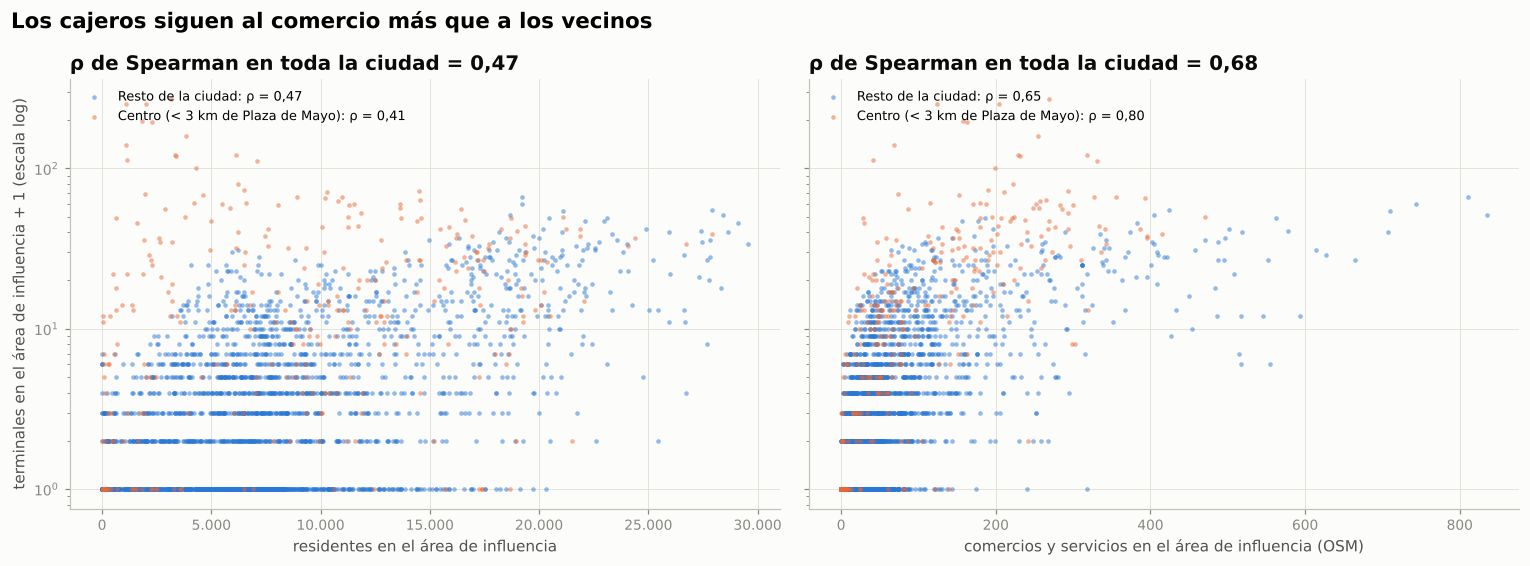

In [10]:
rho = lambda d, x: d[[x, "term_total_k1"]].corr(method="spearman").iloc[0, 1]
centro = modelables["dist_centro_km"] < 3
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for a, x, etiqueta in [(ax[0], "poblacion_k1", "residentes en el área de influencia"),
                       (ax[1], "actividad_osm_k1", "comercios y servicios en el área de influencia (OSM)")]:
    for sub, c, nombre in [(modelables[~centro], e.LINK, "Resto de la ciudad"),
                           (modelables[centro], e.BANELCO, "Centro (< 3 km de Plaza de Mayo)")]:
        a.scatter(sub[x], sub["term_total_k1"] + 1, s=9, color=c, alpha=0.5, linewidths=0,
                  label=f"{nombre}: ρ = {e.num_es(rho(sub, x), 2)}")
    a.set_yscale("log"); a.set_xlabel(etiqueta)
    a.set_title(f"ρ de Spearman en toda la ciudad = {e.num_es(rho(modelables, x), 2)}")
    a.legend(loc="upper left", fontsize=8.5); e.ejes_es(a, x=0)
ax[0].set_ylabel("terminales en el área de influencia + 1 (escala log)")
fig.suptitle("Los cajeros siguen al comercio más que a los vecinos", x=0.01, ha="left", fontweight="bold", fontsize=14)
fig.tight_layout(); fig.savefig(FIG / "eda_comercio_vs_vecinos.png"); plt.show()


**Lectura.** En los dos paneles la relación es positiva, pero es más fuerte con el comercio. El centro (naranja) es
un caso aparte: concentra el 40 % de las terminales con solo el 12 %
de los vecinos, porque la gente que usa esos cajeros trabaja ahí pero no vive ahí.

En clase vimos que una correlación global puede invertirse al separar grupos (paradoja de Simpson). Lo verificamos: acá
**no** pasa. Dentro de cada grupo la relación mantiene el signo, así que la lectura global es confiable.

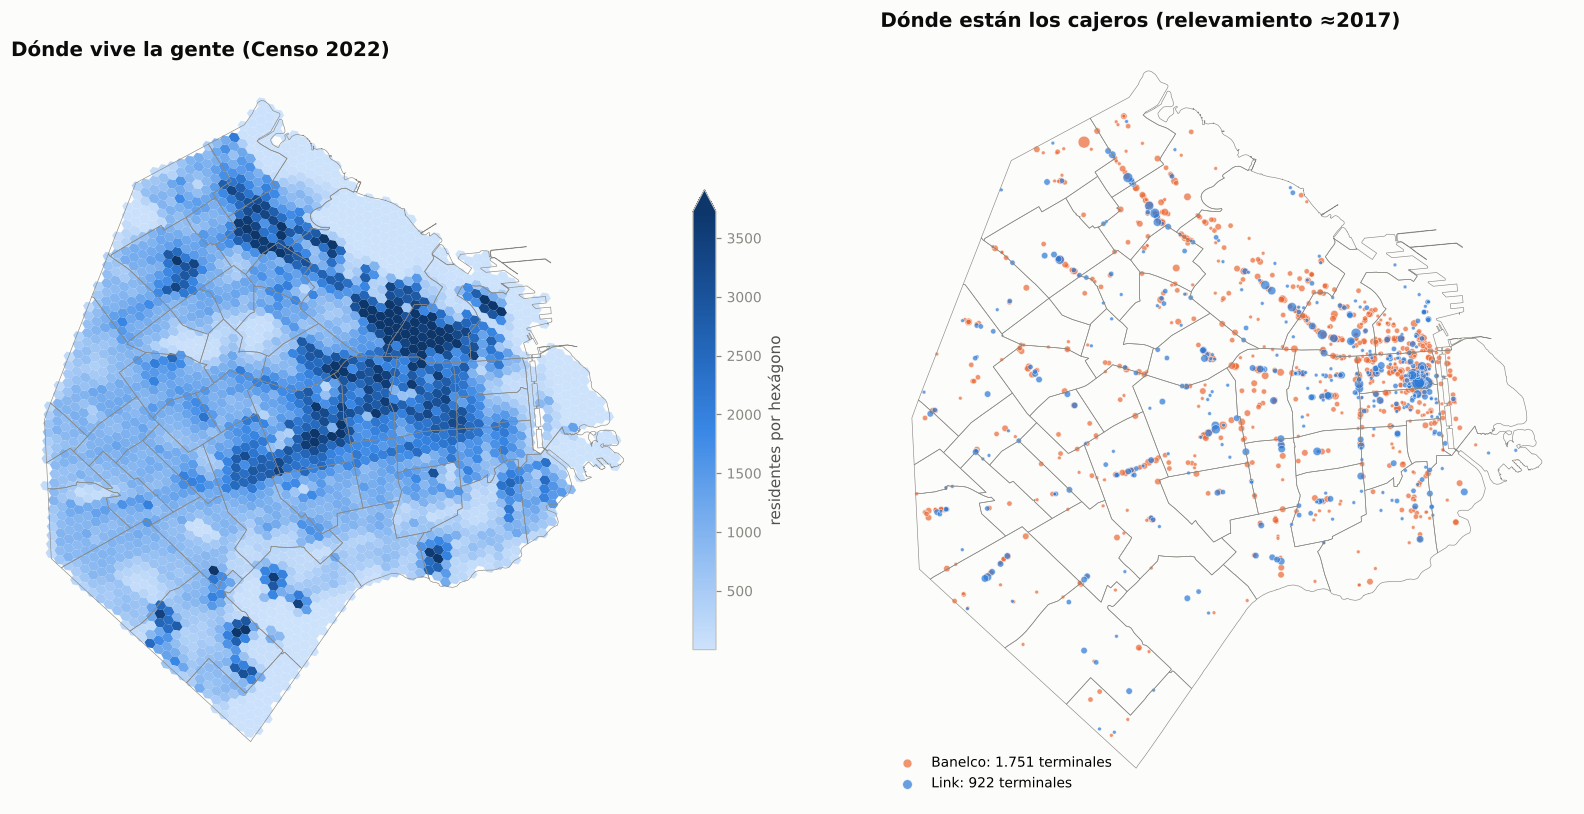

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
g = gpd.GeoDataFrame(hexes, geometry=[f.poligono_hex(h) for h in hexes["h3"]], crs="EPSG:4326")
g.plot(column="poblacion", cmap=e.cmap_secuencial(), ax=ax[0], linewidth=0, vmax=g["poblacion"].quantile(0.98),
       legend=True, legend_kwds={"label": "residentes por hexágono", "shrink": 0.6})
barrios.boundary.plot(ax=ax[0], color=e.TINTA_SUAVE, linewidth=0.4)
ax[0].set_title("Dónde vive la gente (Censo 2022)")
barrios.boundary.plot(ax=ax[1], color=e.TINTA_SUAVE, linewidth=0.4)
for red, c in [("BANELCO", e.BANELCO), ("LINK", e.LINK)]:
    sub = cajeros[cajeros["red"] == red]
    ax[1].scatter(sub["lon"], sub["lat"], s=sub["terminales"] * 6, color=c, alpha=0.7, linewidths=0.4, edgecolors=e.FONDO,
                  label=f"{red.title()}: {e.num_es(sub['terminales'].sum())} terminales")
ax[1].legend(loc="lower left"); ax[1].set_title("Dónde están los cajeros (relevamiento ≈2017)")
for a in ax: a.set_axis_off()
fig.tight_layout(); fig.savefig(FIG / "mapa_poblacion_cajeros.png"); plt.show()


**Lectura.** La población se reparte por toda la ciudad, con más densidad en el eje norte (Palermo, Belgrano), en el
centro geográfico (Balvanera, Almagro, Caballito) y en algunos barrios populares del sur.
Los cajeros, en cambio, se amontonan en el microcentro y sobre las avenidas comerciales. Esa diferencia entre dónde vive
la gente y dónde están los cajeros es justamente lo que el proyecto busca cuantificar.

### Tipo 5 · Otros multivariantes: mapa de calor y burbujas

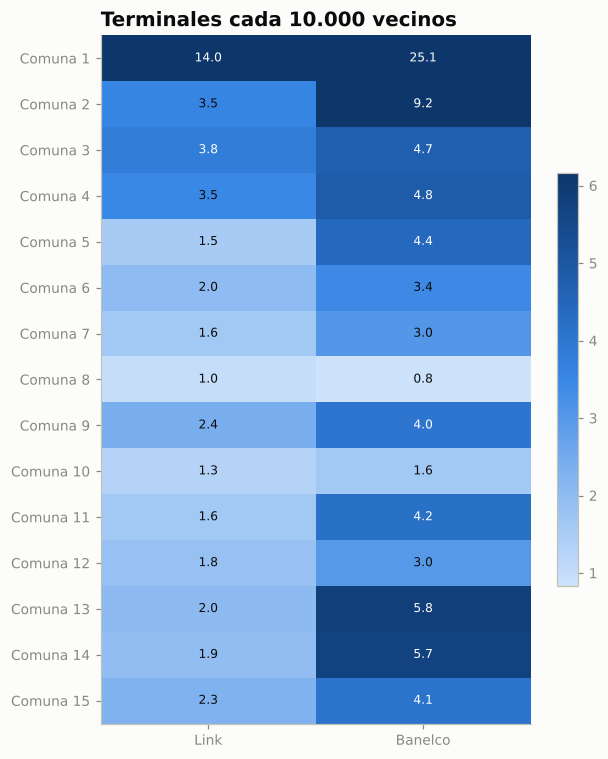

In [12]:
por_barrio = (hexes.groupby(["comuna", "barrio"]).agg(residentes=("poblacion", "sum"), link=("term_link", "sum"),
              banelco=("term_banelco", "sum"), pax=("pax_subte_habil", "sum"), comercio=("actividad_osm", "sum")).reset_index())
por_barrio["link_10mil"] = por_barrio["link"] / por_barrio["residentes"] * 1e4
por_barrio["banelco_10mil"] = por_barrio["banelco"] / por_barrio["residentes"] * 1e4

fig, ax = plt.subplots(figsize=(6, 7))
calor = por_comuna[["link_10mil", "banelco_10mil"]].rename(columns={"link_10mil": "Link", "banelco_10mil": "Banelco"})
im = ax.imshow(calor.values, cmap=e.cmap_secuencial(), aspect="auto", vmax=np.nanquantile(calor.values, 0.9))
ax.set_xticks([0, 1], calor.columns); ax.set_yticks(range(len(calor)), [f"Comuna {c}" for c in calor.index])
for (i, j), v in np.ndenumerate(calor.values):
    ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white" if v > np.nanquantile(calor.values, 0.6) else e.TINTA)
ax.grid(False); ax.set_title("Terminales cada 10.000 vecinos")
fig.colorbar(im, ax=ax, shrink=0.6); fig.tight_layout(); fig.savefig(FIG / "eda_calor_comunas.png"); plt.show()

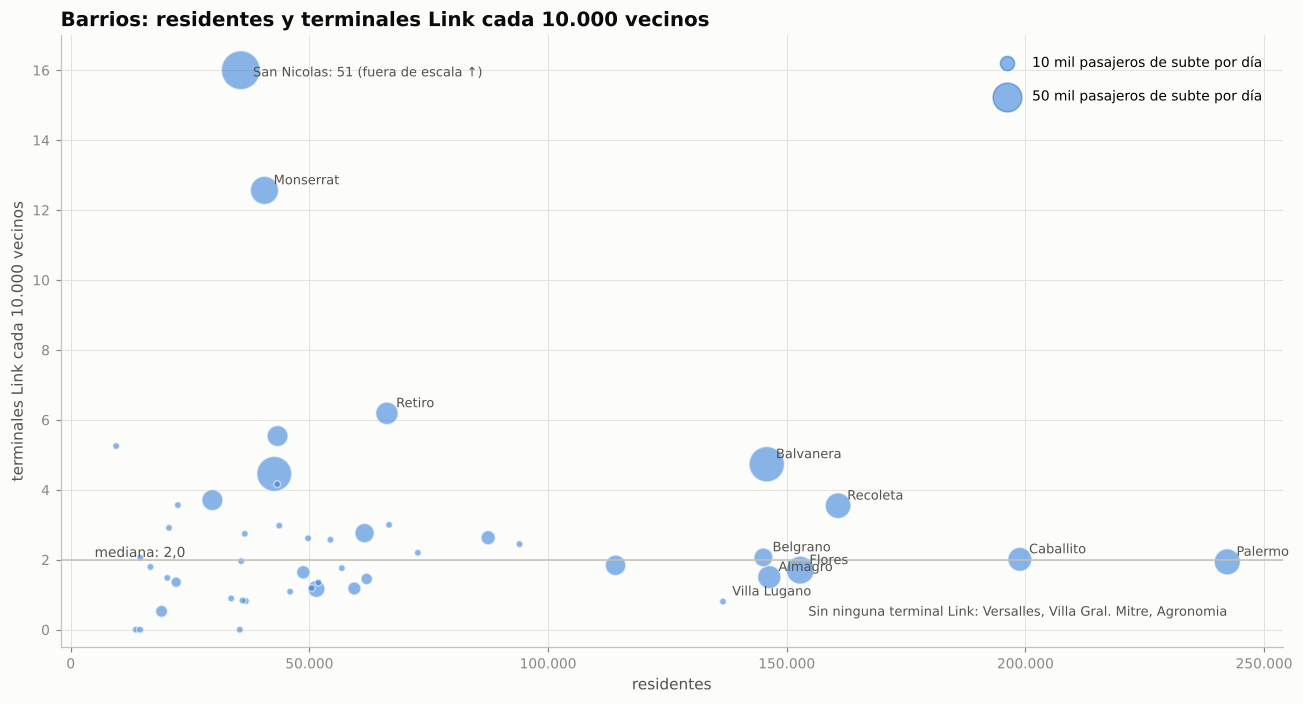

In [13]:
fig, ax = plt.subplots(figsize=(12, 6.5))
pb = por_barrio[por_barrio["residentes"] > 0].copy()
TOPE = 16
tam = lambda pax: 20 + pax / 150
ax.scatter(pb["residentes"], pb["link_10mil"].clip(upper=TOPE), s=tam(pb["pax"]), color=e.LINK, alpha=0.55,
           edgecolors=e.FONDO, linewidths=1)
mediana = pb["link_10mil"].median()
ax.axhline(mediana, color=e.EJE, linewidth=1)
ax.text(5_000, mediana, f"mediana: {e.num_es(mediana, 1)}", va="bottom", color=e.TINTA_2, fontsize=9)
etiquetas = ["Palermo", "Caballito", "Flores", "Balvanera", "Recoleta", "Almagro", "Villa Lugano", "Monserrat", "Retiro", "Belgrano"]
for _, r in pb[pb["barrio"].isin(etiquetas)].iterrows():
    ax.annotate(r["barrio"], (r["residentes"], min(r["link_10mil"], TOPE)), fontsize=8.5, color=e.TINTA_2,
                xytext=(6, 4), textcoords="offset points")
fuera = pb[pb["link_10mil"] > TOPE]
for _, r in fuera.iterrows():
    ax.annotate(f"{r['barrio']}: {e.num_es(r['link_10mil'], 0)} (fuera de escala ↑)", (r["residentes"], TOPE),
                fontsize=8.5, color=e.TINTA_2, xytext=(8, -4), textcoords="offset points")
ceros = pb[pb["link_10mil"] == 0]["barrio"].tolist()
if ceros:
    ax.text(pb["residentes"].max(), 0.4, "Sin ninguna terminal Link: " + ", ".join(ceros), ha="right", fontsize=8.5, color=e.TINTA_2)
for pax, nombre in [(10_000, "10 mil"), (50_000, "50 mil")]:
    ax.scatter([], [], s=tam(pax), color=e.LINK, alpha=0.55, label=f"{nombre} pasajeros de subte por día")
ax.legend(loc="upper right", labelspacing=1.4, borderpad=1)
ax.set(title="Barrios: residentes y terminales Link cada 10.000 vecinos", xlabel="residentes", ylabel="terminales Link cada 10.000 vecinos",
       ylim=(-0.5, TOPE + 1))
e.ejes_es(ax, x=0, y=0)
fig.tight_layout(); fig.savefig(FIG / "eda_burbujas_barrios.png"); plt.show()


**Lectura.** En el mapa de calor, Banelco tiene más terminales por vecino que Link en todas las comunas salvo la
8. En el gráfico de burbujas, los barrios más poblados (a la derecha) quedan cerca
o por debajo de la mediana de terminales Link por vecino (2,0). Villa Lugano, uno de los más
grandes y sin subte, tiene apenas 0,8. Esos barrios grandes y lejos del
centro son los candidatos naturales para sumar cobertura.

## 4. Hallazgos que condicionan el modelado


1. **La oferta es una foto de ≈2017.** La dimensión *oportunidad* falla; el método vale igual, pero los resultados se leen
   como diagnóstico de esa oferta y la app permite cargar el listado actual.
2. **Los cajeros siguen al comercio, no a los vecinos.** La demanda hay que medirla con varias fuentes, no solo con
   población: por eso cruzamos censo, usos del suelo, OpenStreetMap y subte.
3. **Los conteos tienen muchos ceros y cola larga** (78 % de hexágonos sin terminales): modelos de Poisson y
   áreas de influencia en lugar de hexágonos sueltos.
4. **Link es relativamente más fuerte en el sur y más débil en el norte comercial**, donde Banelco domina: hay dos
   oportunidades distintas, competir donde hay demanda y cubrir donde no hay ningún cajero cerca.
5. **OpenStreetMap está incompleto para cajeros**, pero sirve como validación independiente de dónde aparecieron
   cajeros nuevos después de 2017.